# CSE 475 - Assignment 02
## Group Information

| Field | Details |
|---|---|
| **Group ID** | Group G |
| **Student 1 Name** | Aditya Debnath |
| **Student 1 ID** | 2022-2-60-124 |
| **Student 2 Name** | Umme Habiba |
| **Student 2 ID** | 2022-1-60-362 |
| **Student 3 Name** | Purnendu Bhowmik Shuvro |
| **Student 3 ID** | 2023-1-60-085 |
| **Student 4 Name** | Mujahida Nazmoon Naher |
| **Student 4 ID** | 2022-2-60-099 |
| **Notebook Type** | DINO — 100-Epoch (Resume) Notebook |
| **Backbone Used** | DeiT-Small / deit_small_patch16_224 (Best ViT — Assignment 01) |
| **Backbone Init** | timm ImageNet-pretrained weights (pretrained=True), then SSL on unlabelled pool |
| **Dataset Source Name** | Chilli Dataset 2024 |
| **Dataset Source Link** | https://data.mendeley.com/datasets/tf9dtfz9m6/2 |
| **Kaggle Dataset Path** | /kaggle/input/datasets/adityadebnathtirtha/chilli-dataset-2024/Chilli Dataset 2024 |

---
> **Author of this notebook:** Aditya Debnath (core coder). Extends DINO pre-training from epoch 50 to 100 (resume-aware), adds multi-seed evaluation (seeds 42, 0, 123) and the DINO label-fraction ablation (1/5/10/50%).


## 1. Global Configuration

In [1]:
!pip install timm --quiet
print('Libraries ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [2]:
import os, math, time, copy, json, warnings, re
warnings.filterwarnings('ignore')

BASE_DIR   = '/kaggle/input/datasets/adityadebnathtirtha/chilli-dataset-2024/Chilli Dataset 2024'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)
def safe_name(s): return re.sub(r'[^A-Za-z0-9._-]+', '_', str(s)).strip('_')

BACKBONE  = 'deit_small_patch16_224'
EMBED_DIM = 384

IMG_SIZE   = 224
LOCAL_SIZE = 96
SEED       = 42

# --- SSL pre-training (DINO) ---
SSL_EPOCHS         = 100     # final target epoch
SSL_BS             = 64
SSL_LR             = 5e-4
SSL_WD_START       = 0.04
SSL_WD_END         = 0.4
EMA_BASE           = 0.996
N_LOCAL_CROPS      = 6
TEACHER_TEMP_START = 0.04
TEACHER_TEMP_END   = 0.07
TEACHER_WARMUP     = 30
STUDENT_TEMP       = 0.1
CENTER_MOMENTUM    = 0.9
PROJ_OUT_DIM       = 65536
PROJ_HIDDEN        = 2048
PROJ_BOTTLENECK    = 256

# --- Linear probe ---
LP_EPOCHS   = 50
LP_LR       = 0.01
LP_MOMENTUM = 0.9
LP_BS       = 64

KNN_KS = [1, 5, 10, 20, 50, 100, 200]

# --- RESUME settings (Task 4) ---------------------------------------
# Original DINO run stopped at epoch 50 (wall-clock limit). Only
# `dino_backbone.pth` (backbone weights) was saved, so exact resume
# needs a FULL checkpoint; otherwise we warm-start from the backbone.
RESUME_EPOCH       = 50
FULL_CKPT_NAME     = 'dino_full_checkpoint.pth'
BACKBONE_CKPT_NAME = 'dino_backbone.pth'
CKPT_EVERY         = 1
MILESTONE_EPOCHS   = [25, 50, 75, 100]  # named checkpoints kept permanently

# --- Multi-seed evaluation (Task 7) ---
EVAL_SEEDS = [42, 0, 123]

# --- Label-fraction ablation (Task 8) -------------------------------
# "Identical evaluation protocol as BYOL Table IV": BYOL used 25 probe
# epochs, so we match it (set ABLATION_LP_EPOCHS = 25). The work-split
# plan suggests 50 for cross-table consistency -- change the one line
# below to 50 if the team prefers that. Documented for Nazmoon.
FRACS             = [0.01, 0.05, 0.10, 0.50]
ABLATION_LP_EPOCHS = 25

MU  = [0.485, 0.456, 0.406]
SIG = [0.229, 0.224, 0.225]

WALL_LIMIT = 8.5 * 3600
_T0        = time.time()

print('DINO configuration loaded')
print(f'  Backbone   : {BACKBONE}  (embed_dim={EMBED_DIM})')
print(f'  SSL target : {SSL_EPOCHS} ep | bs={SSL_BS} | 2 global + {N_LOCAL_CROPS} local crops')
print(f'  Resume from: epoch {RESUME_EPOCH} (if only backbone weights found)')
print(f'  Eval seeds : {EVAL_SEEDS} | Ablation LP epochs: {ABLATION_LP_EPOCHS}')

DINO configuration loaded
  Backbone   : deit_small_patch16_224  (embed_dim=384)
  SSL target : 100 ep | bs=64 | 2 global + 6 local crops
  Resume from: epoch 50 (if only backbone weights found)
  Eval seeds : [42, 0, 123] | Ablation LP epochs: 25


## 2. Setup and Imports

In [3]:
import random, copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from PIL import Image

import timm
from tqdm import tqdm
try:
    from torch.amp import GradScaler, autocast
    _AMP_DEVICE = "cuda"
except ImportError:
    from torch.cuda.amp import GradScaler, autocast
    _AMP_DEVICE = "cuda"

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                              precision_recall_fscore_support)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
        torch.backends.cudnn.benchmark     = True
        torch.backends.cudnn.deterministic = False

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP    = DEVICE.type == 'cuda'
N_GPU  = torch.cuda.device_count()
print(f'PyTorch {torch.__version__} | timm {timm.__version__}')
print(f'Device: {DEVICE} | GPUs: {N_GPU} | AMP: {AMP}')

PyTorch 2.10.0+cu128 | timm 1.0.26
Device: cuda | GPUs: 2 | AMP: True


## 3. Dataset, Split and Augmentation

Same discovery / split / `SEED=42` as every Group-G notebook (identical SSL /
probe / test partition) plus DINO multi-crop augmentation.

In [4]:
EXTS = {'.jpg','.jpeg','.png','.bmp','.webp','.tiff'}
def discover(root):
    root = Path(root); records = []
    subdirs = [d for d in root.iterdir() if d.is_dir()]
    split_kw = {'train','test','val','valid','Train','Test','Val'}
    if {d.name for d in subdirs}.issubset(split_kw):
        for sp in subdirs:
            for cls in sp.iterdir():
                if cls.is_dir():
                    for f in cls.iterdir():
                        if f.suffix.lower() in EXTS: records.append((str(f), cls.name))
    else:
        for cls in subdirs:
            for f in cls.iterdir():
                if f.suffix.lower() in EXTS: records.append((str(f), cls.name))
    return records

all_records = discover(BASE_DIR)
CLASS_NAMES = sorted({r[1] for r in all_records})
NUM_CLASSES = len(CLASS_NAMES)
C2I         = {c:i for i,c in enumerate(CLASS_NAMES)}
cnt         = Counter(r[1] for r in all_records)
N_TOTAL     = len(all_records)
short       = [c[:18] for c in CLASS_NAMES]
print(f'Total images: {N_TOTAL} | Classes: {NUM_CLASSES}')

Total images: 10987 | Classes: 5


In [5]:
all_paths = [r[0] for r in all_records]
all_lbls  = [C2I[r[1]] for r in all_records]
paths_ssl, paths_rem, lbls_ssl, lbls_rem = train_test_split(
    all_paths, all_lbls, test_size=0.20, stratify=all_lbls, random_state=SEED)
paths_probe, paths_test, lbls_probe, lbls_test = train_test_split(
    paths_rem, lbls_rem, test_size=0.50, stratify=lbls_rem, random_state=SEED)
print(f'SSL: {len(paths_ssl)} | Probe: {len(paths_probe)} | Test: {len(paths_test)}')

SSL: 8789 | Probe: 1099 | Test: 1099


In [6]:
global_aug = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.4, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    T.RandomSolarize(128, p=0.2),
    T.ToTensor(), T.Normalize(MU, SIG),
])
local_aug = T.Compose([
    T.RandomResizedCrop(LOCAL_SIZE, scale=(0.05, 0.4)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    T.RandomGrayscale(p=0.2),
    T.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
    T.ToTensor(), T.Normalize(MU, SIG),
])
eval_tf = T.Compose([
    T.Resize(int(IMG_SIZE * 1.143)), T.CenterCrop(IMG_SIZE),
    T.ToTensor(), T.Normalize(MU, SIG),
])
print('DINO multi-crop augmentation ready (2 global + 6 local).')

DINO multi-crop augmentation ready (2 global + 6 local).


## 4. DINO: Model Definition

Unchanged from the original DINO notebook so resumed weights load cleanly:
DINO head (MLP -> L2-norm -> weight-norm 65536 prototypes), teacher EMA,
running-mean centering, multi-crop.

In [7]:
class DINOHead(nn.Module):
    def __init__(self, in_dim, hidden=PROJ_HIDDEN, bottleneck=PROJ_BOTTLENECK, out_dim=PROJ_OUT_DIM):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, bottleneck),
        )
        self.last = nn.utils.weight_norm(nn.Linear(bottleneck, out_dim, bias=False))
        self.last.weight_g.data.fill_(1)
        self.last.weight_g.requires_grad = False
    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last(x)

class DINONet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(BACKBONE, pretrained=True, num_classes=0, dynamic_img_size=True)
        self.head = DINOHead(EMBED_DIM)
    def forward(self, x): return self.head(self.backbone(x))
    def get_features(self, x): return self.backbone(x)

def _unwrap(net): return net.module if hasattr(net, 'module') else net

print('Building DINO student and teacher...')
student_net = DINONet()
teacher_net = DINONet()
teacher_net.load_state_dict(copy.deepcopy(student_net.state_dict()))
for p in teacher_net.parameters(): p.requires_grad_(False)

if N_GPU > 1:
    student_net = nn.DataParallel(student_net); teacher_net = nn.DataParallel(teacher_net)
    print(f'  DataParallel on {N_GPU} GPUs')
student_net = student_net.to(DEVICE); teacher_net = teacher_net.to(DEVICE)
print(f'  Trainable params: {sum(p.numel() for p in student_net.parameters() if p.requires_grad):,}')

Building DINO student and teacher...


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

  DataParallel on 2 GPUs
  Trainable params: 43,952,256


In [8]:
def dino_loss_fn(s_outs, t_outs, center, tau_s, tau_t):
    t_probs = [(F.softmax((t - center) / tau_t, dim=-1)).detach() for t in t_outs]
    total = 0.; n = 0
    for i_s, s in enumerate(s_outs):
        s_log = F.log_softmax(s / tau_s, dim=-1)
        for i_t, t_p in enumerate(t_probs):
            if i_s == i_t: continue
            total += -(t_p * s_log).sum(dim=-1).mean(); n += 1
    return total / n

def cosine_ema(base, epoch, total): return 1. - (1. - base) * (math.cos(math.pi * epoch / total) + 1.) / 2.
def teacher_temp(epoch):
    if epoch < TEACHER_WARMUP:
        return TEACHER_TEMP_START + (TEACHER_TEMP_END - TEACHER_TEMP_START) * epoch / TEACHER_WARMUP
    return TEACHER_TEMP_END
def wd_cosine(epoch): return SSL_WD_START + (SSL_WD_END - SSL_WD_START) * epoch / SSL_EPOCHS

@torch.no_grad()
def ema_update(student, teacher, tau):
    src = _unwrap(student); tgt = _unwrap(teacher)
    for ps, pt in zip(src.parameters(), tgt.parameters()):
        pt.data.mul_(tau).add_((1. - tau) * ps.data)

@torch.no_grad()
def update_center(center, t_outs):
    batch_c = torch.cat(t_outs, dim=0).mean(dim=0, keepdim=True)
    return center * CENTER_MOMENTUM + batch_c * (1 - CENTER_MOMENTUM)

center = torch.zeros(1, PROJ_OUT_DIM, device=DEVICE)
optimizer = optim.AdamW(_unwrap(student_net).parameters(), lr=SSL_LR, weight_decay=SSL_WD_START)
scaler    = GradScaler(enabled=AMP)
print(f'AdamW lr={SSL_LR} | WD cosine {SSL_WD_START}->{SSL_WD_END} | center mom {CENTER_MOMENTUM}')

AdamW lr=0.0005 | WD cosine 0.04->0.4 | center mom 0.9


## 5. Checkpoint Utilities (resume-aware)

Same three-way logic as the BYOL notebook, adapted for DINO state (student,
teacher, **center buffer**, optimizer, scaler, schedules, RNG):

1. **Full checkpoint** -> exact resume.
2. **Backbone-only** (`dino_backbone.pth`) -> warm start: backbone loaded into
   student + teacher, head/center/optimizer reinitialised, continue from `RESUME_EPOCH`.
3. **Nothing** -> from scratch for 100 epochs.

A full checkpoint is written every epoch from now on.

In [9]:
# ----------------------------------------------------------------------
# Robust checkpoint discovery for Kaggle.
# Prior-run artifacts are typically attached as an INPUT dataset, so we
# search both the live working dir and every /kaggle/input subtree.
# ----------------------------------------------------------------------
import glob

def find_file(filenames, search_roots=None):
    """Return the first existing path matching any name in `filenames`.
    Searches working dir first, then recursively under /kaggle/input."""
    if isinstance(filenames, str):
        filenames = [filenames]
    if search_roots is None:
        search_roots = [OUTPUT_DIR, '/kaggle/working', '/kaggle/input']
    # 1) direct hits in working dirs
    for root in search_roots:
        for name in filenames:
            direct = os.path.join(root, name)
            if os.path.isfile(direct):
                return direct
    # 2) recursive search (handles /kaggle/input/<dataset>/<name>)
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for name in filenames:
            hits = sorted(glob.glob(os.path.join(root, '**', name), recursive=True))
            if hits:
                return hits[0]
    return None

def safe_torch_load(path, map_location='cpu'):
    """torch.load that works across versions (weights_only kwarg added in 2.x)."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


In [10]:
def save_full_checkpoint(epoch):
    ckpt = {
        'epoch'      : epoch,
        'student'    : _unwrap(student_net).state_dict(),
        'teacher'    : _unwrap(teacher_net).state_dict(),
        'center'     : center.detach().cpu(),
        'optimizer'  : optimizer.state_dict(),
        'scaler'     : scaler.state_dict(),
        'ssl_losses' : ssl_losses,
        'tau_history': tau_history,
        'tau_t_hist' : tau_t_hist,
        'rng'        : {
            'python': random.getstate(), 'numpy': np.random.get_state(),
            'torch' : torch.get_rng_state(),
            'cuda'  : (torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None),
        },
        'config': {'SSL_EPOCHS': SSL_EPOCHS, 'SSL_BS': SSL_BS, 'SEED': SEED},
    }
    torch.save(ckpt, f'{OUTPUT_DIR}/{FULL_CKPT_NAME}')

def save_milestone_checkpoint(epoch):
    """Save a NAMED (non-overwriting) checkpoint at milestone epochs.
    File: dino_checkpoint_ep<NNN>.pth  — kept permanently."""
    fname = f'dino_checkpoint_ep{epoch:03d}.pth'
    ckpt = {
        'epoch'      : epoch,
        'student'    : _unwrap(student_net).state_dict(),
        'teacher'    : _unwrap(teacher_net).state_dict(),
        'center'     : center.detach().cpu(),
        'optimizer'  : optimizer.state_dict(),
        'scaler'     : scaler.state_dict(),
        'ssl_losses' : ssl_losses,
        'tau_history': tau_history,
        'tau_t_hist' : tau_t_hist,
        'rng': {
            'python': random.getstate(),
            'numpy' : np.random.get_state(),
            'torch' : torch.get_rng_state(),
            'cuda'  : (torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None),
        },
        'config': {'SSL_EPOCHS': SSL_EPOCHS, 'SSL_BS': SSL_BS, 'SEED': SEED},
    }
    torch.save(ckpt, f'{OUTPUT_DIR}/{fname}')
    print(f'  [Milestone] Saved: {fname}')

def save_best_backbone(epoch):
    """Save dino_best_backbone.pth at epoch 100 — authoritative output."""
    _bb = _unwrap(student_net).backbone
    torch.save(_bb.state_dict(), f'{OUTPUT_DIR}/dino_best_backbone.pth')
    print(f'  [Best] Saved: dino_best_backbone.pth  (epoch {epoch})')

ssl_losses, tau_history, tau_t_hist = [], [], []
start_epoch, resumed_mode = 0, 'scratch'

full_ckpt = find_file([FULL_CKPT_NAME])
back_ckpt = find_file([BACKBONE_CKPT_NAME])

if full_ckpt is not None:
    ck = safe_torch_load(full_ckpt, map_location=DEVICE)
    _unwrap(student_net).load_state_dict(ck['student'])
    _unwrap(teacher_net).load_state_dict(ck['teacher'])
    center = ck['center'].to(DEVICE)
    optimizer.load_state_dict(ck['optimizer'])
    try: scaler.load_state_dict(ck['scaler'])
    except Exception as e: print('  (scaler skipped:', e, ')')
    ssl_losses  = list(ck.get('ssl_losses', []))
    tau_history = list(ck.get('tau_history', []))
    tau_t_hist  = list(ck.get('tau_t_hist', []))
    start_epoch = int(ck['epoch'])
    rng = ck.get('rng', {})
    try:
        if rng.get('python') is not None: random.setstate(rng['python'])
        if rng.get('numpy')  is not None: np.random.set_state(rng['numpy'])
        if rng.get('torch')  is not None: torch.set_rng_state(rng['torch'].cpu() if hasattr(rng['torch'],'cpu') else rng['torch'])
        if rng.get('cuda')   is not None and torch.cuda.is_available(): torch.cuda.set_rng_state_all(rng['cuda'])
    except Exception as e:
        print('  (RNG restore skipped:', e, ')')
    resumed_mode = 'exact'
    print(f'EXACT RESUME from {full_ckpt}; restored through epoch {start_epoch}.')

elif back_ckpt is not None:
    sd = safe_torch_load(back_ckpt, map_location=DEVICE)
    _unwrap(student_net).backbone.load_state_dict(sd, strict=False)
    _unwrap(teacher_net).backbone.load_state_dict(sd, strict=False)
    start_epoch  = RESUME_EPOCH
    resumed_mode = 'warm'
    print(f'WARM START from backbone weights: {back_ckpt}')
    print('  Backbone -> student + teacher. Head/center/optimizer freshly initialised.')
    print(f'  Continuing from epoch {RESUME_EPOCH} -> {SSL_EPOCHS}.')
else:
    print(f'No checkpoint found. Training DINO from scratch for {SSL_EPOCHS} epochs.')

print(f'\nStart epoch = {start_epoch} | mode = {resumed_mode}')

No checkpoint found. Training DINO from scratch for 100 epochs.

Start epoch = 0 | mode = scratch


## 6. DINO: Pre-Training Loop (epoch start+1 -> 100)

In [11]:
class DINODataset(Dataset):
    def __init__(self, paths): self.paths = paths
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        g1, g2 = global_aug(img), global_aug(img)
        locs   = [local_aug(img) for _ in range(N_LOCAL_CROPS)]
        return g1, g2, locs

def dino_collate(batch):
    g1   = torch.stack([b[0] for b in batch])
    g2   = torch.stack([b[1] for b in batch])
    locs = [torch.stack([b[2][i] for b in batch]) for i in range(N_LOCAL_CROPS)]
    return g1, g2, locs

dino_ssl_ds = DINODataset(paths_ssl)
ssl_loader  = DataLoader(dino_ssl_ds, batch_size=SSL_BS, shuffle=True,
                         collate_fn=dino_collate, num_workers=8, pin_memory=True, drop_last=True)
_b = next(iter(ssl_loader))
assert len(_b) == 3, 'Batch must be (g1, g2, [locals]) — label-free.'
print(f'DINO SSL loader: {len(dino_ssl_ds)} images | batch {SSL_BS} | label-free CONFIRMED')

DINO SSL loader: 8789 images | batch 64 | label-free CONFIRMED


In [12]:
# Track the actual last completed epoch (correct for scratch/warm/exact resume)
last_epoch = start_epoch
if start_epoch >= SSL_EPOCHS:
    print(f'Already at/over target ({start_epoch} >= {SSL_EPOCHS}). Skipping SSL training.')
else:
    print(f'Training epochs {start_epoch+1} -> {SSL_EPOCHS} (mode={resumed_mode})')
    print('=' * 70)
    for epoch in range(start_epoch + 1, SSL_EPOCHS + 1):
        if time.time() - _T0 > WALL_LIMIT:
            print(f'Wall-clock limit at epoch {epoch}. Saving and stopping.')
            save_full_checkpoint(epoch - 1); break
        tau_ema = cosine_ema(EMA_BASE, epoch - 1, SSL_EPOCHS)
        tau_t   = teacher_temp(epoch - 1)
        for pg in optimizer.param_groups: pg['weight_decay'] = wd_cosine(epoch - 1)
        student_net.train(); teacher_net.eval()
        epoch_loss = 0.
        pbar = tqdm(ssl_loader, desc=f'[DINO {epoch:>3}/{SSL_EPOCHS}]', leave=False, ncols=92, unit='batch')
        for g1, g2, locs in pbar:
            g1, g2 = g1.to(DEVICE), g2.to(DEVICE)
            locs   = [l.to(DEVICE) for l in locs]
            all_views = [g1, g2] + locs
            with autocast(device_type=_AMP_DEVICE, enabled=AMP):
                with torch.no_grad():
                    t_out1 = teacher_net(g1); t_out2 = teacher_net(g2)
                s_outs = [student_net(v) for v in all_views]
                loss   = dino_loss_fn(s_outs, [t_out1, t_out2], center, STUDENT_TEMP, tau_t)
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(_unwrap(student_net).parameters(), 3.0)
            scaler.step(optimizer); scaler.update()
            ema_update(student_net, teacher_net, tau_ema)
            with torch.no_grad():
                center[:] = update_center(center, [t_out1, t_out2])
            epoch_loss += loss.item()
            pbar.set_postfix(loss=f'{loss.item():.3f}', tau_t=f'{tau_t:.3f}')
        ssl_losses.append(epoch_loss / len(ssl_loader))
        tau_history.append(tau_ema); tau_t_hist.append(tau_t)
        last_epoch = epoch          # last fully completed epoch
        if epoch % CKPT_EVERY == 0:
            save_full_checkpoint(epoch)
        if epoch in MILESTONE_EPOCHS:
            save_milestone_checkpoint(epoch)
        if epoch % 5 == 0 or epoch == start_epoch + 1 or epoch == SSL_EPOCHS:
            print(f'Epoch [{epoch:>3}/{SSL_EPOCHS}]  Loss: {ssl_losses[-1]:.4f}  '
                  f'tau_t: {tau_t:.4f}  Elapsed: {(time.time()-_T0)/60:.1f} min')

# ── Post-training saves ─────────────────────────────────────────────────
_bb = _unwrap(student_net).backbone
# 1. Plain backbone — used by linear-probe / comparison cells downstream
torch.save(_bb.state_dict(), f'{OUTPUT_DIR}/{BACKBONE_CKPT_NAME}')
# 2. Rolling full checkpoint (overwrites) — captures exact state where we stopped
_final_epoch = last_epoch          # = epochs actually reached (handles exact resume correctly)
save_full_checkpoint(_final_epoch)
# 3. Milestone checkpoint for the final epoch if it lands on one
if _final_epoch in MILESTONE_EPOCHS:
    save_milestone_checkpoint(_final_epoch)
# 4. Mark completion at epoch 100
if _final_epoch >= SSL_EPOCHS:
    save_best_backbone(_final_epoch)
    print(f'Training COMPLETE: reached epoch {_final_epoch}/{SSL_EPOCHS}.')
else:
    print(f'Training PAUSED at epoch {_final_epoch}/{SSL_EPOCHS} — resume next session.')
print('Saved:', BACKBONE_CKPT_NAME, '+', FULL_CKPT_NAME)
print(f'New epochs trained this session: {len(ssl_losses)}')

Training epochs 1 -> 100 (mode=scratch)


Epoch [  1/100]  Loss: 11.0594  tau_t: 0.0400  Elapsed: 12.1 min


Epoch [  5/100]  Loss: 10.8273  tau_t: 0.0440  Elapsed: 55.1 min


Epoch [ 10/100]  Loss: 9.2878  tau_t: 0.0490  Elapsed: 108.8 min


Epoch [ 15/100]  Loss: 8.5126  tau_t: 0.0540  Elapsed: 162.6 min


...

Epoch [ 30/100]  Loss: 7.4747  tau_t: 0.0690  Elapsed: 324.7 min


Epoch [ 35/100]  Loss: 7.3430  tau_t: 0.0700  Elapsed: 378.4 min


Epoch [ 40/100]  Loss: 7.2077  tau_t: 0.0700  Elapsed: 432.1 min


Epoch [ 45/100]  Loss: 7.1053  tau_t: 0.0700  Elapsed: 485.9 min


Wall-clock limit at epoch 49. Saving and stopping.
Training PAUSED at epoch 48/100 — resume next session.
Saved: dino_backbone.pth + dino_full_checkpoint.pth
New epochs trained this session: 48


## 7. DINO: Training Curve (this session)

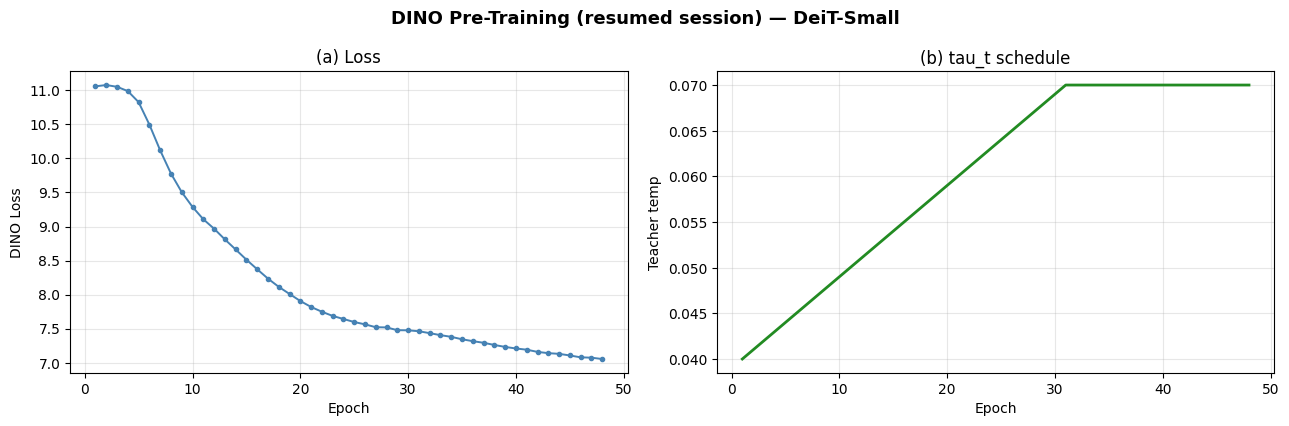

Loss 11.0594 -> 7.0530 over epochs 1-48


In [13]:
if len(ssl_losses) == 0:
    print('No new epochs trained this session (nothing to plot).')
else:
    x0 = start_epoch + 1
    xs = list(range(x0, x0 + len(ssl_losses)))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
    fig.suptitle('DINO Pre-Training (resumed session) — DeiT-Small', fontsize=13, fontweight='bold')
    axes[0].plot(xs, ssl_losses, color='steelblue', lw=1.4, marker='o', ms=3)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('DINO Loss'); axes[0].set_title('(a) Loss'); axes[0].grid(alpha=0.3)
    axes[1].plot(xs, tau_t_hist, color='forestgreen', lw=2.0)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Teacher temp'); axes[1].set_title('(b) tau_t schedule'); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/dino_100ep_training_curve.png', dpi=150, bbox_inches='tight'); plt.show()
    print(f'Loss {ssl_losses[0]:.4f} -> {ssl_losses[-1]:.4f} over epochs {xs[0]}-{xs[-1]}')

## 8. Linear Probing — primary run (seed 42)

Frozen DINO backbone + `nn.Linear(384, num_classes)` on the 10% probe set.

In [14]:
class LabelledDs(Dataset):
    def __init__(self, paths, labels, tf): self.paths=paths; self.labels=labels; self.tf=tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB')), self.labels[i]

probe_ds = LabelledDs(paths_probe, lbls_probe, eval_tf)
test_ds  = LabelledDs(paths_test,  lbls_test,  eval_tf)
probe_loader = DataLoader(probe_ds, batch_size=LP_BS, shuffle=True,  num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=LP_BS, shuffle=False, num_workers=8, pin_memory=True)

dino_backbone = _unwrap(student_net).backbone
dino_backbone.eval()
for p in dino_backbone.parameters(): p.requires_grad_(False)
print(f'Probe: {len(probe_ds)} | Test: {len(test_ds)} (backbone frozen)')

Probe: 1099 | Test: 1099 (backbone frozen)


In [15]:
def train_linear_probe(backbone, seed, epochs=LP_EPOCHS, return_curves=False):
    set_seed(seed)
    head  = nn.Linear(EMBED_DIM, NUM_CLASSES).to(DEVICE)
    opt   = optim.SGD(head.parameters(), lr=LP_LR, momentum=LP_MOMENTUM)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.CrossEntropyLoss()
    loader = DataLoader(probe_ds, batch_size=LP_BS, shuffle=True, num_workers=8,
                        pin_memory=True, generator=torch.Generator().manual_seed(seed))
    tr_loss, te_acc, best_acc, best_state = [], [], 0., None
    for ep in range(1, epochs + 1):
        head.train(); el = 0.
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            with torch.no_grad(): feats = backbone(imgs)
            loss = crit(head(feats), lbls)
            opt.zero_grad(); loss.backward(); opt.step(); el += loss.item()
        sched.step(); tr_loss.append(el / len(loader))
        head.eval(); c = t = 0
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                c += (head(backbone(imgs)).argmax(1) == lbls).sum().item(); t += lbls.size(0)
        acc = c / t * 100; te_acc.append(acc)
        if acc > best_acc: best_acc, best_state = acc, copy.deepcopy(head.state_dict())
    head.load_state_dict(best_state)
    head.eval(); preds, true, probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            logits = head(backbone(imgs.to(DEVICE)))
            probs.append(torch.softmax(logits, 1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().numpy()); true.extend(lbls.numpy())
    preds, true = np.array(preds), np.array(true)
    top1 = (preds == true).mean() * 100
    mf1  = f1_score(true, preds, average='macro')
    pr, rc, _, _ = precision_recall_fscore_support(true, preds, average='macro')
    out = {'top1': top1, 'macro_f1': mf1, 'macro_prec': pr*100, 'macro_rec': rc*100,
           'best_acc': best_acc, 'preds': preds, 'true': true}
    if return_curves: out.update({'tr_loss': tr_loss, 'te_acc': te_acc})
    return out

print('Running primary linear probe (seed 42)...')
lp = train_linear_probe(dino_backbone, 42, return_curves=True)
dino_top1, dino_macro_f1 = lp['top1'], lp['macro_f1']
prec, rec = lp['macro_prec'], lp['macro_rec']
all_preds, all_true = lp['preds'], lp['true']
f1_cls = f1_score(all_true, all_preds, average=None, labels=list(range(NUM_CLASSES)))
print('=' * 56)
print(f'  DINO Linear Probe (seed 42) — Top-1: {dino_top1:.2f}%')
print(f'  Macro F1: {dino_macro_f1:.4f} | Prec: {prec:.2f}% | Rec: {rec:.2f}%')
print('=' * 56)
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, digits=4))

Running primary linear probe (seed 42)...
  DINO Linear Probe (seed 42) — Top-1: 92.45%
  Macro F1: 0.9247 | Prec: 92.69% | Rec: 92.60%
                 precision    recall  f1-score   support

     cercospora     0.9543    0.8468    0.8974       222
        healthy     0.9296    0.9000    0.9145       220
mites_and_trips     0.9474    0.9323    0.9398       251
    nutritional     0.8178    0.9507    0.8793       203
 powdery mildew     0.9854    1.0000    0.9927       203

       accuracy                         0.9245      1099
      macro avg     0.9269    0.9260    0.9247      1099
   weighted avg     0.9283    0.9245    0.9248      1099



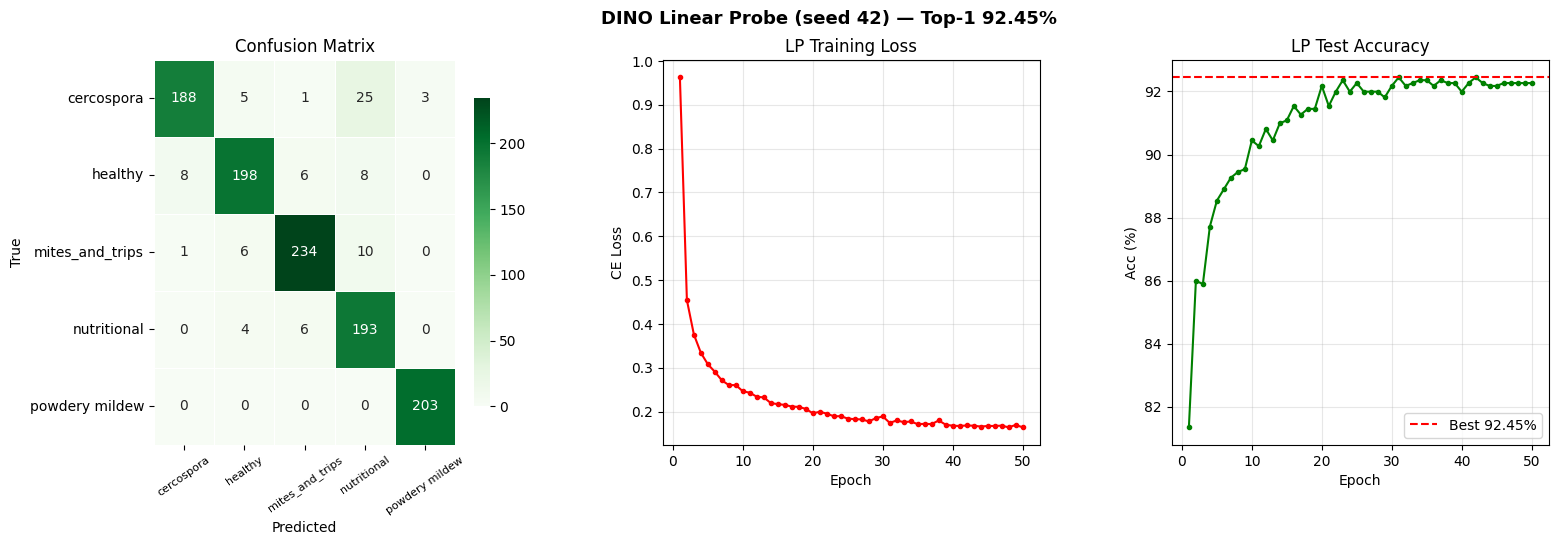

Saved: dino_100ep_lp_results.png


In [16]:
fig = plt.figure(figsize=(18, 5))
gs  = fig.add_gridspec(1, 3, wspace=0.35)
fig.suptitle(f'DINO Linear Probe (seed 42) — Top-1 {dino_top1:.2f}%', fontsize=13, fontweight='bold')
ax = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=short, yticklabels=short, linewidths=0.4, cbar_kws={'shrink':0.8})
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion Matrix')
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax = fig.add_subplot(gs[0, 1])
ax.plot(range(1, LP_EPOCHS+1), lp['tr_loss'], 'r-o', ms=3); ax.grid(alpha=0.3)
ax.set_title('LP Training Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('CE Loss')
ax = fig.add_subplot(gs[0, 2])
ax.plot(range(1, LP_EPOCHS+1), lp['te_acc'], 'g-o', ms=3)
ax.axhline(lp['best_acc'], color='red', ls='--', label=f"Best {lp['best_acc']:.2f}%")
ax.set_title('LP Test Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Acc (%)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/dino_100ep_lp_results.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: dino_100ep_lp_results.png')

## 9. k-NN Evaluation

     k    Accuracy
     1      95.18%
     5      89.90%
    10      83.26%
    20      81.07%
    50      75.61%
   100      73.25%
   200      69.88%
k=20 (comparison table): 81.07%


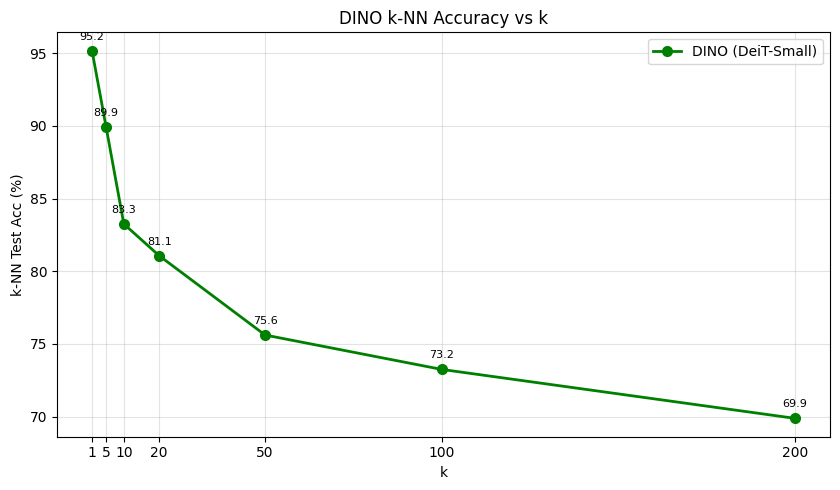

In [17]:
def extract_feats(backbone, loader, desc='Extracting'):
    backbone.eval(); feats, labs = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=desc, leave=False, ncols=80):
            f = F.normalize(backbone(imgs.to(DEVICE)), dim=-1)
            feats.append(f.cpu().numpy()); labs.append(lbls.numpy())
    return np.vstack(feats), np.concatenate(labs)

probe_feats, probe_labs = extract_feats(dino_backbone, probe_loader, 'Probe')
test_feats,  test_labs  = extract_feats(dino_backbone, test_loader,  'Test ')

dino_knn_accs = []
print(f'{"k":>6}  {"Accuracy":>10}')
for k in KNN_KS:
    knn = KNeighborsClassifier(n_neighbors=min(k, len(probe_feats)), metric='cosine', n_jobs=-1)
    knn.fit(probe_feats, probe_labs)
    acc = knn.score(test_feats, test_labs) * 100
    dino_knn_accs.append(acc); print(f'{k:>6}  {acc:>9.2f}%')
dino_knn20 = dino_knn_accs[KNN_KS.index(20)] if 20 in KNN_KS else None
print(f'k=20 (comparison table): {dino_knn20:.2f}%')

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(KNN_KS, dino_knn_accs, 'g-o', ms=7, lw=2, label='DINO (DeiT-Small)')
ax.set_xlabel('k'); ax.set_ylabel('k-NN Test Acc (%)'); ax.set_xticks(KNN_KS)
ax.set_title('DINO k-NN Accuracy vs k'); ax.grid(alpha=0.35); ax.legend()
for xi, yi in zip(KNN_KS, dino_knn_accs):
    ax.annotate(f'{yi:.1f}', (xi, yi), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/dino_100ep_knn.png', dpi=150, bbox_inches='tight'); plt.show()

## 10. Multi-Seed Evaluation — Task 7  (seeds 42, 0, 123)

Fixed backbone; re-run the linear-probe evaluation per seed and aggregate.
k-NN is deterministic for a fixed backbone/split (std ≈ 0).

In [18]:
per_seed = []
for s in EVAL_SEEDS:
    print(f'\n--- Linear probe @ seed {s} ---')
    r = train_linear_probe(dino_backbone, s)
    print(f'  Top-1={r["top1"]:.2f}%  F1={r["macro_f1"]:.4f}  Prec={r["macro_prec"]:.2f}%  Rec={r["macro_rec"]:.2f}%')
    per_seed.append(r)

def agg(key):
    v = np.array([r[key] for r in per_seed], dtype=float)
    return float(v.mean()), float(v.std())

knn20_seed = []
for s in EVAL_SEEDS:
    set_seed(s)
    knn = KNeighborsClassifier(n_neighbors=min(20, len(probe_feats)), metric='cosine', n_jobs=-1)
    knn.fit(probe_feats, probe_labs)
    knn20_seed.append(knn.score(test_feats, test_labs) * 100)
knn20_mean, knn20_std = float(np.mean(knn20_seed)), float(np.std(knn20_seed))

acc_m, acc_s = agg('top1'); f1_m, f1_s = agg('macro_f1')
pre_m, pre_s = agg('macro_prec'); rec_m, rec_s = agg('macro_rec')

print('\n' + '=' * 64)
print('  DINO MULTI-SEED LINEAR-PROBE SUMMARY  (seeds ' + str(EVAL_SEEDS) + ')')
print('=' * 64)
print(f'  Mean Accuracy   : {acc_m:.2f} %  (std {acc_s:.2f})')
print(f'  Mean Macro-F1   : {f1_m:.4f}    (std {f1_s:.4f})')
print(f'  Mean Precision  : {pre_m:.2f} %  (std {pre_s:.2f})')
print(f'  Mean Recall     : {rec_m:.2f} %  (std {rec_s:.2f})')
print(f'  Mean k-NN(k=20) : {knn20_mean:.2f} %  (std {knn20_std:.2f})')
print('=' * 64)

multiseed = {
    'seeds': EVAL_SEEDS,
    'accuracy' : {'mean': round(acc_m,2), 'std': round(acc_s,2),
                  'per_seed': [round(r['top1'],2) for r in per_seed]},
    'macro_f1' : {'mean': round(f1_m,4), 'std': round(f1_s,4),
                  'per_seed': [round(r['macro_f1'],4) for r in per_seed]},
    'precision': {'mean': round(pre_m,2), 'std': round(pre_s,2)},
    'recall'   : {'mean': round(rec_m,2), 'std': round(rec_s,2)},
    'knn20'    : {'mean': round(knn20_mean,2), 'std': round(knn20_std,2)},
}
with open(f'{OUTPUT_DIR}/dino_100ep_multiseed.json', 'w') as fh:
    json.dump(multiseed, fh, indent=2)
print('Saved: dino_100ep_multiseed.json')


--- Linear probe @ seed 42 ---
  Top-1=92.45%  F1=0.9247  Prec=92.69%  Rec=92.60%

--- Linear probe @ seed 0 ---
  Top-1=92.63%  F1=0.9264  Prec=92.83%  Rec=92.76%

--- Linear probe @ seed 123 ---
  Top-1=92.08%  F1=0.9210  Prec=92.30%  Rec=92.22%

  DINO MULTI-SEED LINEAR-PROBE SUMMARY  (seeds [42, 0, 123])
  Mean Accuracy   : 92.39 %  (std 0.23)
  Mean Macro-F1   : 0.9240    (std 0.0023)
  Mean Precision  : 92.61 %  (std 0.22)
  Mean Recall     : 92.52 %  (std 0.22)
  Mean k-NN(k=20) : 81.07 %  (std 0.00)
Saved: dino_100ep_multiseed.json


## 11. Label-Fraction Ablation — Task 8

Linear probe on the frozen DINO backbone at **1%, 5%, 10%, 50%** of the probe
labels, mirroring BYOL Table IV. `ABLATION_LP_EPOCHS` (Section 1) controls the
per-fraction probe length; it is set to **25** to match BYOL's protocol exactly.
Set it to 50 if the team standardises on the longer schedule.

In [19]:
abl_lp_accs, abl_knn20_accs = [], []
arr_probe = np.array(paths_probe); arr_lbls = np.array(lbls_probe)
crit = nn.CrossEntropyLoss()

print(f'DINO label-fraction ablation  (LP epochs/fraction = {ABLATION_LP_EPOCHS})')
print(f'{"Fraction":>10}  {"N labels":>9}  {"LP Top-1":>10}  {"k-NN k=20":>11}')
print('-' * 48)
for frac in FRACS:
    set_seed(SEED)
    n_keep = max(NUM_CLASSES, int(frac * len(arr_probe)))
    if n_keep < len(arr_probe):
        sss = StratifiedShuffleSplit(n_splits=1, train_size=n_keep, random_state=SEED)
        idx, _ = next(sss.split(arr_probe, arr_lbls))
        fp, fl = arr_probe[idx], arr_lbls[idx]
    else:
        fp, fl = arr_probe, arr_lbls
    frac_ds  = LabelledDs(list(fp), list(fl), eval_tf)
    frac_ldr = DataLoader(frac_ds, batch_size=LP_BS, shuffle=True, num_workers=8, pin_memory=True)

    head = nn.Linear(EMBED_DIM, NUM_CLASSES).to(DEVICE)
    opt  = optim.SGD(head.parameters(), lr=LP_LR, momentum=LP_MOMENTUM)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ABLATION_LP_EPOCHS)
    for _ in range(ABLATION_LP_EPOCHS):
        head.train()
        for imgs, lbs in frac_ldr:
            imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
            with torch.no_grad(): f = dino_backbone(imgs)
            loss = crit(head(f), lbs); opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
    head.eval(); c = t = 0
    with torch.no_grad():
        for imgs, lbs in test_loader:
            imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
            c += (head(dino_backbone(imgs)).argmax(1) == lbs).sum().item(); t += lbs.size(0)
    lp_acc = c / t * 100; abl_lp_accs.append(lp_acc)

    ff, fl2 = extract_feats(dino_backbone, frac_ldr, f'Feats {frac:.0%}')
    k20 = KNeighborsClassifier(n_neighbors=min(20, len(ff)), metric='cosine', n_jobs=-1)
    k20.fit(ff, fl2)
    knn20_acc = k20.score(test_feats, test_labs) * 100; abl_knn20_accs.append(knn20_acc)
    print(f'{frac:>10.0%}  {len(frac_ds):>9}  {lp_acc:>9.2f}%  {knn20_acc:>10.2f}%')

DINO label-fraction ablation  (LP epochs/fraction = 25)
  Fraction   N labels    LP Top-1    k-NN k=20
------------------------------------------------


        1%         10      49.77%       20.20%


        5%         54      68.24%       55.96%


       10%        109      76.52%       63.88%


       50%        549      86.99%       75.16%


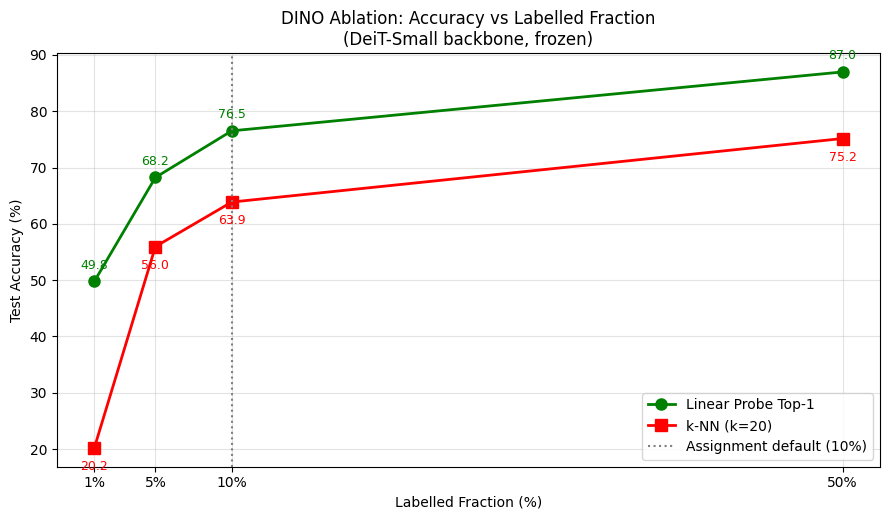

Saved: dino_ablation_label_fraction.png


In [20]:
frac_pct = [f*100 for f in FRACS]
fig, ax = plt.subplots(figsize=(9, 5.3))
ax.plot(frac_pct, abl_lp_accs,    'g-o', ms=8, lw=2, label='Linear Probe Top-1')
ax.plot(frac_pct, abl_knn20_accs, 'r-s', ms=8, lw=2, label='k-NN (k=20)')
ax.axvline(10, color='gray', ls=':', lw=1.5, label='Assignment default (10%)')
ax.set_xlabel('Labelled Fraction (%)'); ax.set_ylabel('Test Accuracy (%)')
ax.set_title('DINO Ablation: Accuracy vs Labelled Fraction\n(DeiT-Small backbone, frozen)')
ax.set_xticks(frac_pct); ax.set_xticklabels([f'{f:.0f}%' for f in frac_pct])
ax.grid(alpha=0.35); ax.legend()
for xi, y1, y2 in zip(frac_pct, abl_lp_accs, abl_knn20_accs):
    ax.annotate(f'{y1:.1f}', (xi, y1), textcoords='offset points', xytext=(0,9), ha='center', fontsize=9, color='green')
    ax.annotate(f'{y2:.1f}', (xi, y2), textcoords='offset points', xytext=(0,-16), ha='center', fontsize=9, color='red')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/dino_ablation_label_fraction.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: dino_ablation_label_fraction.png')

## 12. Save Results + BYOL/DINO Comparison

In [21]:
dino_results = {
    'backbone'   : BACKBONE,
    'ssl_epochs' : _final_epoch,          # true epochs reached this run (scratch/warm/exact-safe)
    'resume_mode': resumed_mode,
    'lp_top1'    : round(dino_top1, 2),
    'macro_f1'   : round(dino_macro_f1, 4),
    'macro_prec' : round(prec, 2),
    'macro_rec'  : round(rec, 2),
    'knn_accs'   : {str(k): round(a,2) for k,a in zip(KNN_KS, dino_knn_accs)},
    'knn20'      : round(dino_knn20, 2) if dino_knn20 is not None else None,
    'multiseed'  : multiseed,
    'ablation'   : {'lp_epochs': ABLATION_LP_EPOCHS,
                    'fractions': FRACS,
                    'lp_top1':  [round(a,2) for a in abl_lp_accs],
                    'knn20':    [round(a,2) for a in abl_knn20_accs]},
    'per_class_f1': {c: round(float(f1_cls[i]),4) for i,c in enumerate(CLASS_NAMES)},
}
with open(f'{OUTPUT_DIR}/dino_results.json','w') as fh:
    json.dump(dino_results, fh, indent=2)
np.save(f'{OUTPUT_DIR}/dino_knn_accs.npy', np.array(dino_knn_accs))
print('Saved: dino_results.json | dino_knn_accs.npy')

# Optional BYOL comparison if its results were attached
br = None
bpath = find_file(['byol_results.json'])
if bpath:
    with open(bpath) as fh: br = json.load(fh)

print('\n' + '=' * 86)
print('  BYOL vs DINO — 100-epoch comparison (LP seed 42, multi-seed mean +/- std)')
print('=' * 86)
print(f'  {"Method":<12}{"Epochs":>7}{"LP Top-1":>11}{"LP mean+/-std":>18}{"k-NN20":>9}{"Macro F1":>10}')
print('-' * 86)
if br:
    bm = br.get('multiseed', {}).get('accuracy', {})
    print(f'  {"BYOL":<12}{br.get("ssl_epochs",""):>7}{br.get("lp_top1",0):>10.2f}%'
          f'{(str(bm.get("mean","-"))+" +/- "+str(bm.get("std","-"))):>18}'
          f'{(br.get("knn20") or 0):>8.2f}%{br.get("macro_f1",0):>10.4f}')
else:
    print(f'  {"BYOL":<12}{"(attach byol_results.json to compare)":<60}')
print(f'  {"DINO":<12}{dino_results["ssl_epochs"]:>7}{dino_top1:>10.2f}%'
      f'{(str(multiseed["accuracy"]["mean"])+" +/- "+str(multiseed["accuracy"]["std"])):>18}'
      f'{(dino_knn20 or 0):>8.2f}%{dino_macro_f1:>10.4f}')
print('=' * 86)

Saved: dino_results.json | dino_knn_accs.npy

  BYOL vs DINO — 100-epoch comparison (LP seed 42, multi-seed mean +/- std)
  Method       Epochs   LP Top-1     LP mean+/-std   k-NN20  Macro F1
--------------------------------------------------------------------------------------
  BYOL        (attach byol_results.json to compare)                       
  DINO             48     92.45%    92.39 +/- 0.23   81.07%    0.9247


## 13. Final Summary + Notes for the Team

In [22]:
print('=' * 60)
print('  DINO_100ep — FINAL SUMMARY')
print('=' * 60)
print(f'  Resume mode      : {resumed_mode}')
print(f'  LP Top-1 (s=42)  : {dino_top1:.2f}%')
print(f'  LP Top-1 (mean)  : {acc_m:.2f}% +/- {acc_s:.2f}')
print(f'  Macro F1 (mean)  : {f1_m:.4f} +/- {f1_s:.4f}')
print(f'  k-NN k=20        : {dino_knn20:.2f}%')
print(f'  Ablation LP@1/5/10/50%: ' + ', '.join(f'{a:.1f}%' for a in abl_lp_accs))
print('=' * 60)
for f in ['dino_backbone.pth', FULL_CKPT_NAME, 'dino_results.json', 'dino_knn_accs.npy',
          'dino_100ep_multiseed.json', 'dino_100ep_lp_results.png',
          'dino_100ep_knn.png', 'dino_ablation_label_fraction.png']:
    print('  saved:', f)

  DINO_100ep — FINAL SUMMARY
  Resume mode      : scratch
  LP Top-1 (s=42)  : 92.45%
  LP Top-1 (mean)  : 92.39% +/- 0.23
  Macro F1 (mean)  : 0.9240 +/- 0.0023
  k-NN k=20        : 81.07%
  Ablation LP@1/5/10/50%: 49.8%, 68.2%, 76.5%, 87.0%
  saved: dino_backbone.pth
  saved: dino_full_checkpoint.pth
  saved: dino_results.json
  saved: dino_knn_accs.npy
  saved: dino_100ep_multiseed.json
  saved: dino_100ep_lp_results.png
  saved: dino_100ep_knn.png
  saved: dino_ablation_label_fraction.png


**Notes for the team**

- **Backbone init:** timm ImageNet-pretrained DeiT-Small, then DINO (Task 1) — no A01 checkpoint.
- **Resume mode** printed in Section 5 (`exact` / `warm` / `scratch`). Full checkpoints are saved every epoch for exact wall-clock resume.
- **Ablation epochs:** `ABLATION_LP_EPOCHS = 25` to match BYOL Table IV exactly. The work-split plan flags the 25-vs-50 inconsistency — switch to 50 in Section 1 if standardising. Note this for Nazmoon's Table IV footnote.
- Hand `dino_*.json` / `.npy` / `.png` to **Shuvro → Umme** for verification.